# 🍷 Pipeline Completo de ML — **Classificação**
### Pós-Graduação em Ciência de Dados | Melhores Práticas End-to-End
**Dataset:** Wine Quality (UCI ML Repository) | **Tarefa:** Prever se um vinho é de alta qualidade (score ≥ 7)

---
> **Como usar este notebook:** Execute as células em ordem. Cada seção tem comentários explicativos detalhados.  
> Tempo estimado de execução completa: **~10–15 minutos** (Boruta + Optuna são os mais lentos).

| Etapa | Conteúdo |
|-------|----------|
| 1 | Análise Exploratória de Dados (EDA) |
| 2 | Feature Engineering |
| 3 | Seleção de Features — Boruta |
| 4 | Modelo Baseline |
| 5 | Modelos SOTA (RF, XGBoost, LightGBM, CatBoost) |
| 6 | Métricas de Performance |
| 7 | Tunagem de Hiperparâmetros — Optuna |
| 8 | Interpretabilidade — SHAP |


## ⚙️ Célula 0 — Instalação de Dependências
> Execute apenas uma vez e aguarde o kernel reiniciar automaticamente se necessário.

In [1]:
# ============================================================
# INSTALAÇÃO — Execute esta célula primeiro
# O Colab já tem sklearn, pandas, numpy, matplotlib, seaborn
# Precisamos instalar apenas as bibliotecas extras
# ============================================================
!pip install -q boruta shap optuna lightgbm catboost xgboost

print("✅ Instalação concluída! Prossiga para a próxima célula.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
✅ Instalação concluída! Prossiga para a próxima célula.


## 📦 Célula 1 — Imports

In [2]:
# ============================================================
# IMPORTS — organizados por categoria para fácil manutenção
# ============================================================

# Dados
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style="whitegrid", palette="muted")

# Pré-processamento
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Feature Selection
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

# Hiperparâmetros
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretabilidade
import shap

print("✅ Todas as bibliotecas importadas com sucesso!")
print(f"   NumPy {np.__version__} | Pandas {pd.__version__} | Optuna {optuna.__version__}")


✅ Todas as bibliotecas importadas com sucesso!
   NumPy 2.0.2 | Pandas 2.2.2 | Optuna 4.8.0


---
## 📌 Etapa 1 — Análise Exploratória de Dados (EDA)

> **Por que fazer EDA?**  
> A EDA é a "conversa com os dados". Antes de qualquer modelagem precisamos entender distribuições,  
> detectar anomalias e correlações. **Pular esta etapa é o erro mais comum de iniciantes.**


In [3]:
# ============================================================
# CARREGAMENTO DO DATASET
#
# Usamos vinho tinto + branco do UCI para um dataset mais rico.
# Adicionamos a feature 'type' como variável categórica.
# Criamos a variável-alvo BINÁRIA: alta_qualidade = score >= 7
#
# ⚠️ Esta é uma DECISÃO DE NEGÓCIO — sempre documente o critério!
# ============================================================

url_red   = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red   = pd.read_csv(url_red,   sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['type']   = 'red'
df_white['type'] = 'white'
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

# Target binário: 1 = alta qualidade (score >= 7), 0 = baixa/média
df['high_quality'] = (df['quality'] >= 7).astype(int)

print(f"Shape do dataset  : {df.shape}")
print(f"\nDistribuição do target:")
vc = df['high_quality'].value_counts()
for label, count in vc.items():
    tag = "Alta Qualidade (1)" if label == 1 else "Baixa/Média  (0)"
    print(f"  {tag}: {count:,} ({count/len(df)*100:.1f}%)")
df.head()


Shape do dataset  : (6497, 14)

Distribuição do target:
  Baixa/Média  (0): 5,220 (80.3%)
  Alta Qualidade (1): 1,277 (19.7%)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0


In [4]:
# ============================================================
# ESTATÍSTICAS DESCRITIVAS
# Preste atenção em: min/max absurdos, std muito alta,
# diferença grande entre média e mediana (assimetria).
# ============================================================
print("=" * 60)
print("INFORMAÇÕES GERAIS")
print("=" * 60)
df.info()
print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
df.describe().T.round(3)


INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
 13  high_quality          6497 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 710

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000


In [5]:
# ============================================================
# VALORES AUSENTES
#
# Sempre verifique: (1) quantidade e (2) padrão de missingness
# MCAR: falta completamente ao acaso (ok imputar)
# MAR:  falta relacionada a outras variáveis (cuidado)
# MNAR: falta relacionada ao próprio valor (problema sério)
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Qtd': missing, '%': missing_pct})
missing_df  = missing_df[missing_df['Qtd'] > 0]

if missing_df.empty:
    print("✅ Nenhum valor ausente encontrado.")
    print("\n💡 Nota didática: Em datasets reais você frequentemente encontrará")
    print("   valores ausentes. Estratégias: imputação por mediana/média,")
    print("   KNN Imputer, ou modelos nativos (LightGBM, CatBoost).")
else:
    print(missing_df.sort_values('%', ascending=False))


✅ Nenhum valor ausente encontrado.

💡 Nota didática: Em datasets reais você frequentemente encontrará
   valores ausentes. Estratégias: imputação por mediana/média,
   KNN Imputer, ou modelos nativos (LightGBM, CatBoost).


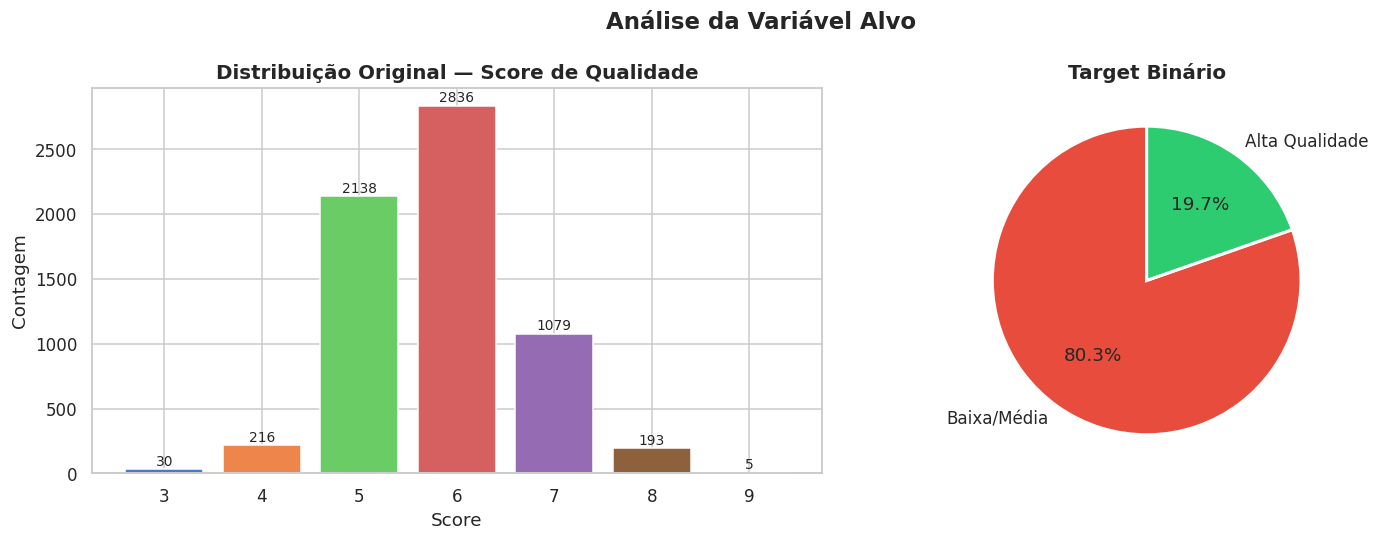

Razão de balanceamento: 0.24
⚠️  Dataset desbalanceado → use class_weight='balanced' e métricas F1/AUC.


In [6]:
# ============================================================
# DISTRIBUIÇÃO DO TARGET E BALANCEAMENTO DE CLASSES
#
# O desbalanceamento é um dos problemas mais críticos em
# classificação. Um modelo que sempre diz "classe 0" pode
# ter alta acurácia com dados desbalanceados → use F1 e AUC!
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score original
score_counts = df['quality'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
            color=sns.color_palette("muted", len(score_counts)), edgecolor='white')
axes[0].set_title('Distribuição Original — Score de Qualidade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Contagem')
for s, c in zip(score_counts.index, score_counts.values):
    axes[0].text(s, c + 30, str(c), ha='center', fontsize=9)

# Plot 2: Target binário
vc = df['high_quality'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=['Baixa/Média', 'Alta Qualidade'],
    autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Target Binário', fontsize=13, fontweight='bold')

plt.suptitle('Análise da Variável Alvo', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

ratio = vc.min() / vc.max()
print(f"Razão de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️  Dataset desbalanceado → use class_weight='balanced' e métricas F1/AUC.")
else:
    print("✅ Classes relativamente balanceadas.")


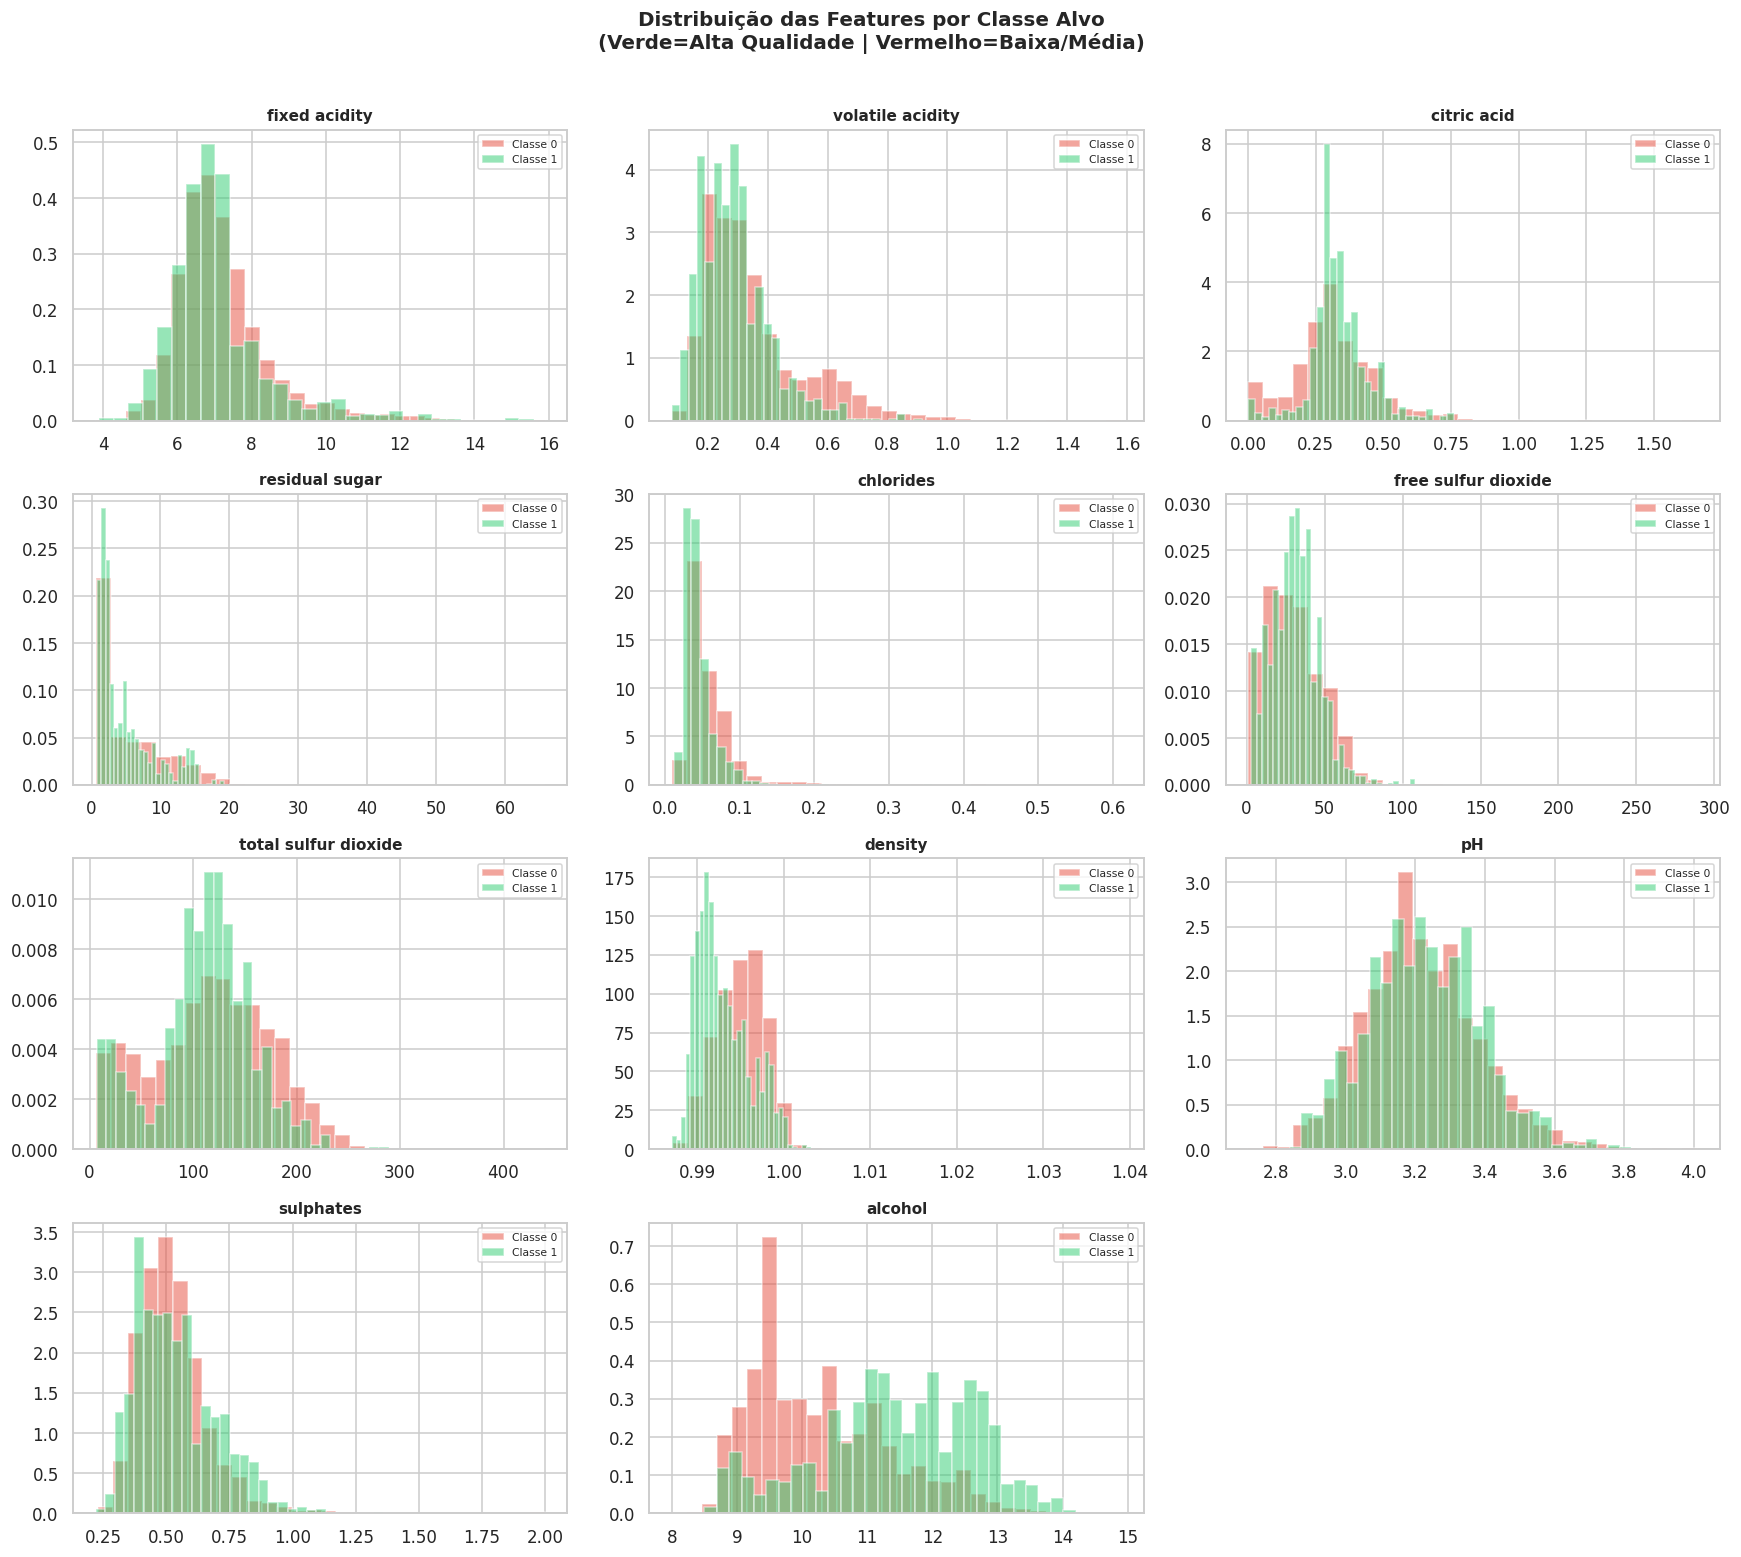

In [7]:
# ============================================================
# DISTRIBUIÇÕES DAS FEATURES POR CLASSE
#
# Histogramas sobrepostos por classe revelam features com
# boa separabilidade (candidatas a features importantes).
# Se as distribuições se sobrepõem muito → feature fraca.
# ============================================================
numeric_features = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in ['quality', 'high_quality']]

n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for label, color in zip([0, 1], ['#e74c3c', '#2ecc71']):
        axes[i].hist(df[df['high_quality']==label][feat],
                     bins=30, alpha=0.5, color=color,
                     label=f'Classe {label}', density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribuição das Features por Classe Alvo\n'
             '(Verde=Alta Qualidade | Vermelho=Baixa/Média)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


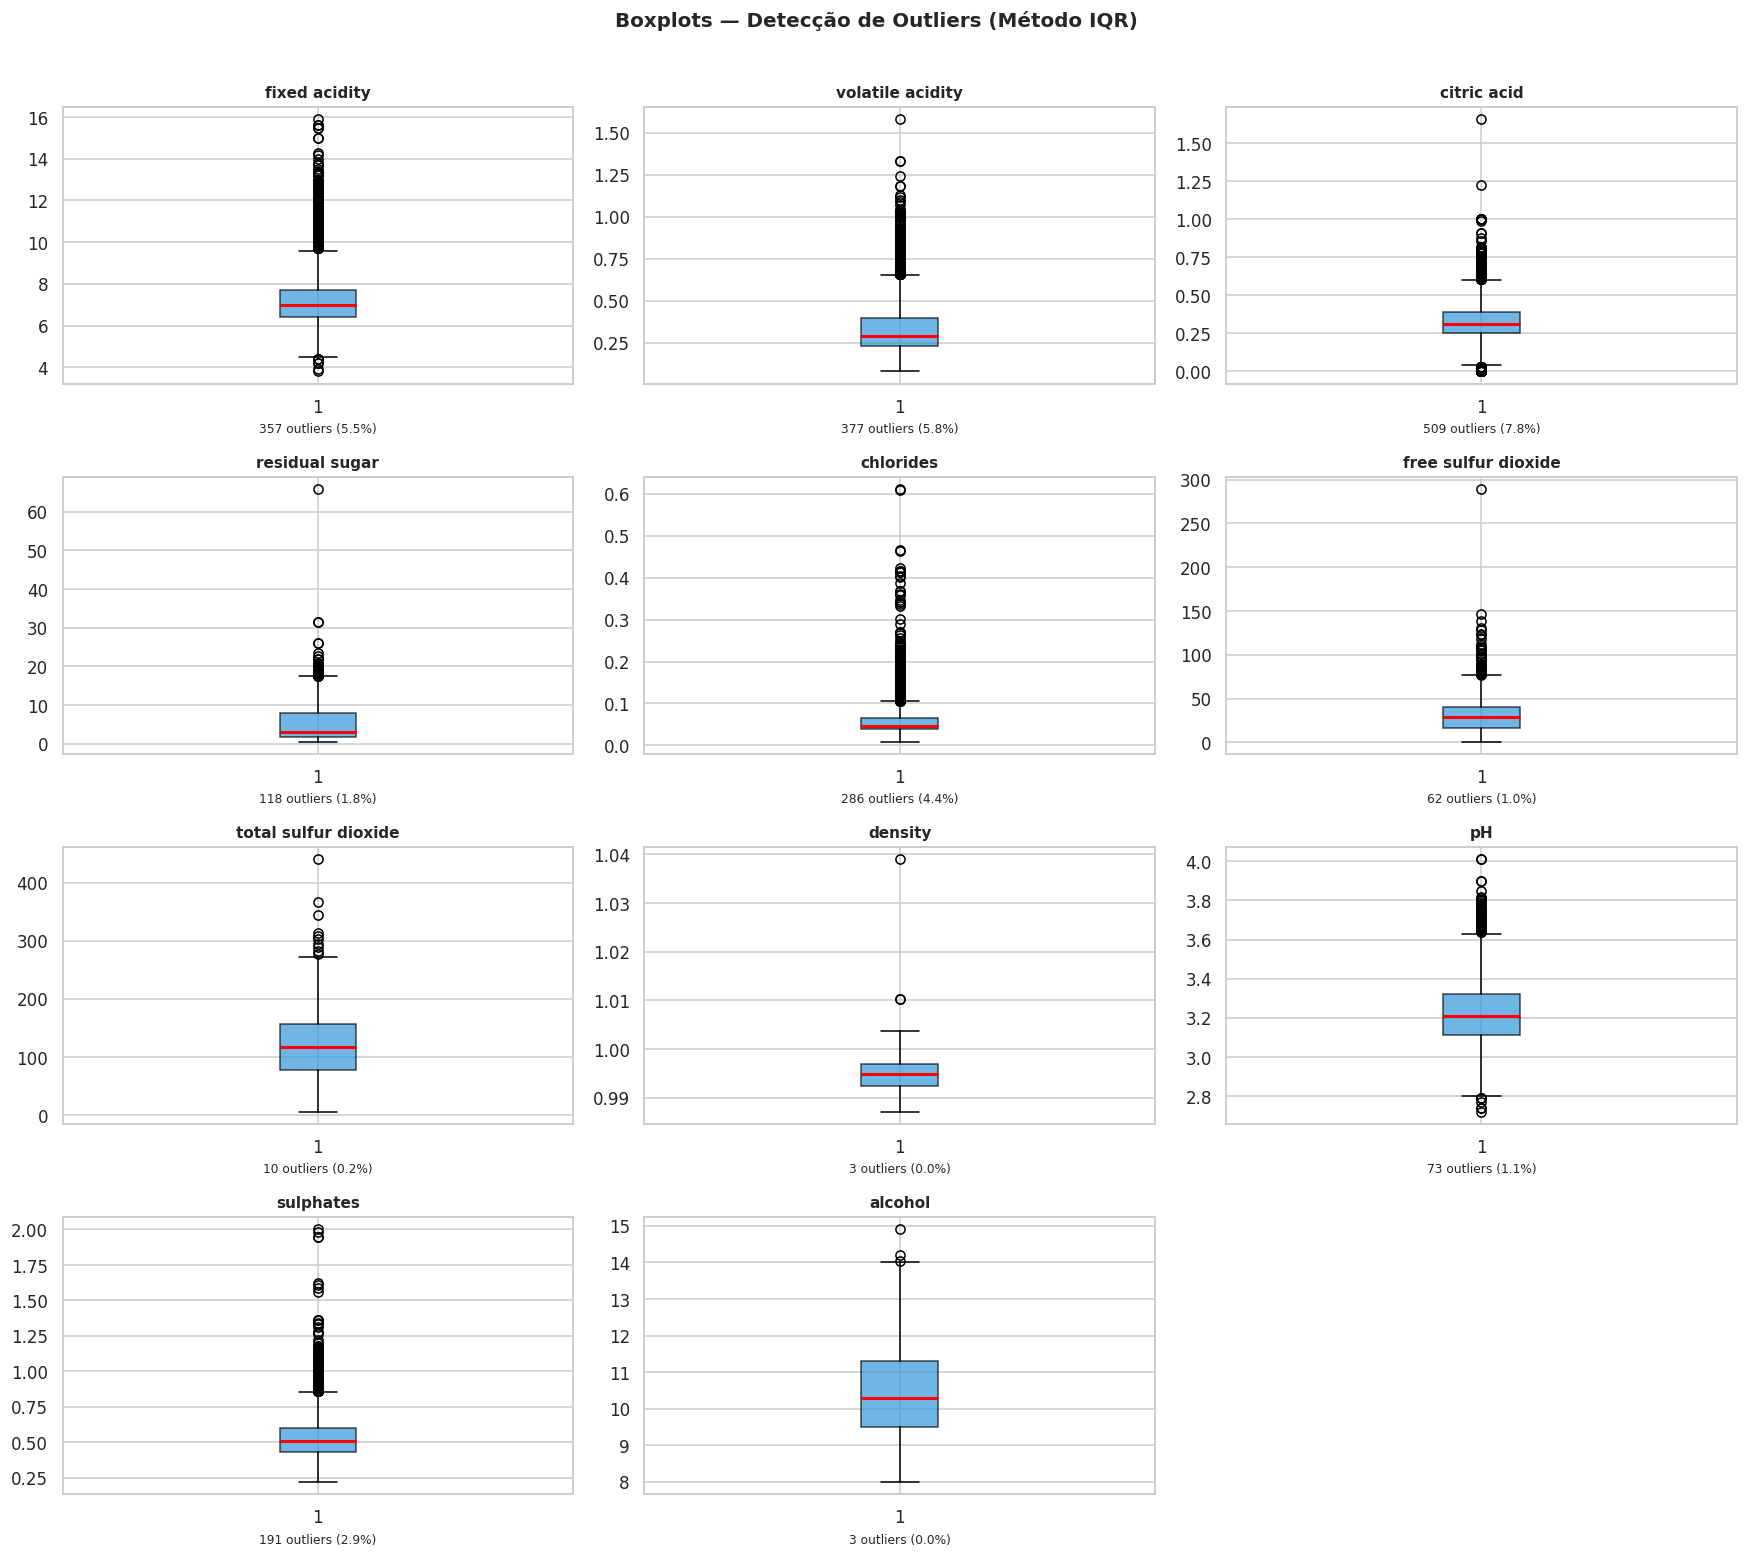


Resumo de outliers por feature:
citric acid             509
volatile acidity        377
fixed acidity           357
chlorides               286
sulphates               191
residual sugar          118
pH                       73
free sulfur dioxide      62
total sulfur dioxide     10
density                   3
alcohol                   3


In [8]:
# ============================================================
# DETECÇÃO DE OUTLIERS — MÉTODO IQR
#
# IQR (Interquartile Range): outlier quando:
#   x < Q1 - 1.5*IQR  ou  x > Q3 + 1.5*IQR
#
# Modelos de árvore (RF, XGBoost, LightGBM, CatBoost) são
# ROBUSTOS a outliers por natureza — não precisam ser removidos!
# Modelos lineares e redes neurais são sensíveis → tratar.
# ============================================================
n_rows2 = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows2, n_cols, figsize=(16, n_rows2 * 3.5))
axes = axes.flatten()

outlier_info = {}
for i, feat in enumerate(numeric_features):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1-1.5*IQR)|(df[feat] > Q3+1.5*IQR)).sum()
    outlier_info[feat] = n_out
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'{n_out} outliers ({n_out/len(df)*100:.1f}%)', fontsize=8)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplots — Detecção de Outliers (Método IQR)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("\nResumo de outliers por feature:")
print(pd.Series(outlier_info).sort_values(ascending=False).to_string())


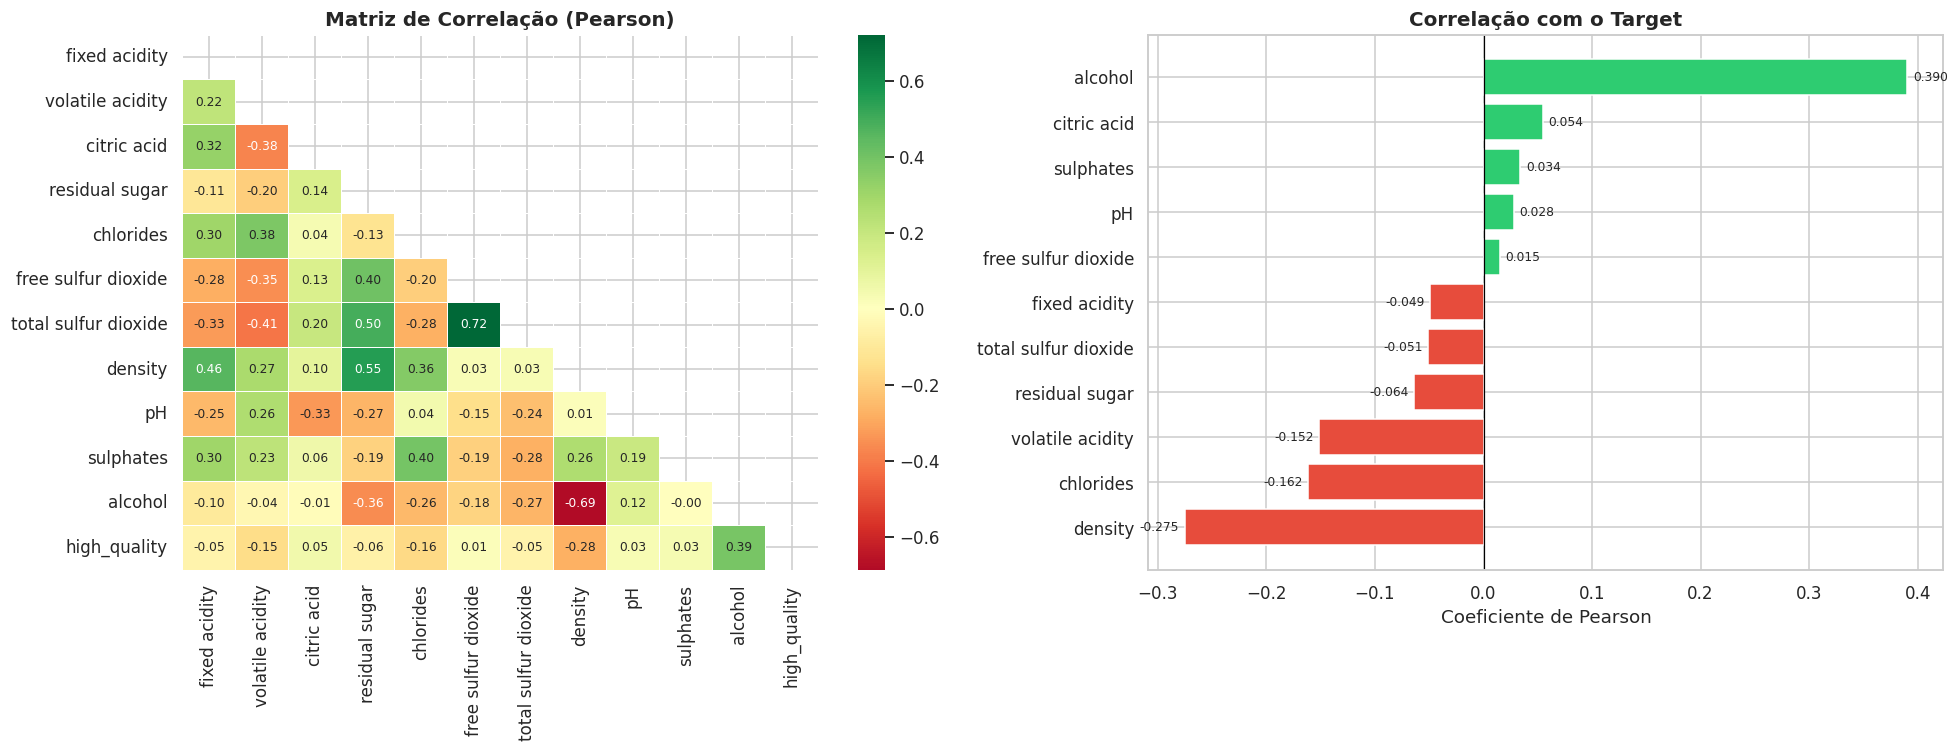


Top 5 features mais correlacionadas com o target:
alcohol             0.390486
density             0.275441
chlorides           0.161781
volatile acidity    0.151714
residual sugar      0.063992


In [9]:
# ============================================================
# ANÁLISE DE CORRELAÇÃO
#
# Pearson mede correlação LINEAR. Para relações não-lineares,
# use Spearman (rank-based) ou analise com scatter plots.
#
# ATENÇÃO: Correlação ≠ Causalidade!
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df[numeric_features + ['high_quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title('Matriz de Correlação (Pearson)', fontsize=13, fontweight='bold')

target_corr = corr['high_quality'].drop('high_quality').sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Correlação com o Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')

for val, feat in zip(target_corr.values, target_corr.index):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), feat,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout(); plt.show()
print("\nTop 5 features mais correlacionadas com o target:")
print(target_corr.abs().sort_values(ascending=False).head(5).to_string())


---
## ⚙️ Etapa 2 — Feature Engineering

> **Conceito:** Feature Engineering é a arte de transformar dados brutos em representações  
> mais informativas. É frequentemente onde residem os **maiores ganhos de performance** —  
> mais do que a escolha do algoritmo em si.


In [10]:
# ============================================================
# SEPARAÇÃO FEATURES / TARGET
#
# ATENÇÃO CRÍTICA: removemos 'quality' pois ela VAZA o target!
# (high_quality foi derivado diretamente de quality)
# Incluir 'quality' seria DATA LEAKAGE — erro gravíssimo.
# ============================================================
TARGET = 'high_quality'
X = df.drop(columns=['quality', TARGET]).copy()
y = df[TARGET].copy()

print(f"Shape X: {X.shape} | Shape y: {y.shape}")
print(f"Features categóricas : {X.select_dtypes('object').columns.tolist()}")
print(f"Features numéricas   : {X.select_dtypes(np.number).columns.tolist()}")


Shape X: (6497, 12) | Shape y: (6497,)
Features categóricas : ['type']
Features numéricas   : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [11]:
# ============================================================
# CODIFICAÇÃO DA VARIÁVEL CATEGÓRICA 'type'
#
# One-Hot Encoding: ideal para variáveis com baixa cardinalidade
# e SEM ordinalidade (red/white não têm ordem natural).
#
# Para alta cardinalidade (ex: cidade com 500 categorias):
#   → use Target Encoding (category_encoders.TargetEncoder)
#   → SEMPRE dentro do fold de CV para evitar data leakage!
#
# drop_first=True evita a "dummy variable trap" (multicolinearidade)
# ============================================================
X = pd.get_dummies(X, columns=['type'], drop_first=True, dtype=int)
# Resultado: type_white = 1 → vinho branco; 0 → vinho tinto

print(f"Após OHE: {X.shape[1]} features")
print(f"Nova feature: {[c for c in X.columns if 'type' in c]}")
X.head(3)


Após OHE: 12 features
Nova feature: ['type_white']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0


In [12]:
# ============================================================
# CRIAÇÃO DE NOVAS FEATURES — Conhecimento de Domínio
#
# Boas features vêm de entender O PROBLEMA, não só os dados.
# Aqui aplicamos conhecimento sobre química do vinho:
# ============================================================

# 1. Acidez total: combina ácidos fixos e voláteis
X['total_acidity'] = X['fixed acidity'] + X['volatile acidity']

# 2. Razão álcool/açúcar: vinhos secos têm alto álcool e baixo açúcar
#    Adicionar epsilon (1e-8) para evitar divisão por zero
X['alcohol_sugar_ratio'] = X['alcohol'] / (X['residual sugar'] + 1e-8)

# 3. Proporção de SO2 livre: SO2 livre é o conservante ativo
#    Maior proporção → melhor preservação do vinho
X['free_so2_ratio'] = X['free sulfur dioxide'] / (X['total sulfur dioxide'] + 1e-8)

# 4. Interação álcool × densidade: álcool é menos denso que água
X['alcohol_density'] = X['alcohol'] * X['density']

print(f"✅ 4 novas features criadas via conhecimento de domínio")
print(f"Shape final X: {X.shape}")


✅ 4 novas features criadas via conhecimento de domínio
Shape final X: (6497, 16)


In [13]:
# ============================================================
# DIVISÃO TREINO/TESTE
#
# REGRA DE OURO:
#   • Fit do Scaler/Encoder → APENAS no treino
#   • Transform           → treino E teste
#
# Fazer fit no dataset completo antes do split = DATA LEAKAGE!
# O modelo "vê" o futuro durante o treinamento → métricas infladas.
#
# stratify=y mantém a proporção de classes em ambos os conjuntos.
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),  columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),       columns=X_test.columns)

print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")
print(f"Proporção positivos — Treino: {y_train.mean():.3f} | Teste: {y_test.mean():.3f}")
print("\n✅ Padronização aplicada corretamente (fit apenas no treino).")


Treino: 5,197 | Teste: 1,300
Proporção positivos — Treino: 0.196 | Teste: 0.197

✅ Padronização aplicada corretamente (fit apenas no treino).


---
## 🔍 Etapa 3 — Seleção de Features com **Boruta**

> **Como funciona o Boruta:**  
> 1. Para cada feature real, cria uma **"shadow feature"** (cópia com valores embaralhados)  
> 2. Treina um Random Forest com features reais + shadow features juntas  
> 3. Uma feature real é relevante se sua importância > **max(shadow importances)**  
> 4. Repete N vezes e usa **teste binomial** para decidir com rigor estatístico  
>
> **Saída:** `CONFIRMED` (relevante) | `TENTATIVE` (incerto) | `REJECTED` (ruído)  
>
> **Vantagem vs correlação simples:** captura relações não-lineares e interações entre features.


In [14]:
# ============================================================
# BORUTA FEATURE SELECTION
#
# n_estimators='auto': Boruta determina o mínimo necessário
# max_iter=50: número de rodadas do processo de seleção
# alpha=0.05: nível de significância do teste estatístico
#
# ⏱️ Tempo estimado: 3-8 minutos dependendo do hardware do Colab
# ============================================================
rf_boruta = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'  # Crucial para datasets desbalanceados
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    verbose=2,
    random_state=42,
    max_iter=50,
    alpha=0.05
)

print("🔍 Executando Boruta... (pode levar alguns minutos)\n")
boruta.fit(X_train_scaled.values, y_train.values)
print("\n✅ Boruta concluído!")


🔍 Executando Boruta... (pode levar alguns minutos)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	10 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	11 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	12 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	13 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	14 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	15 / 50
Confirmed: 	15
Tentative: 	1
Rejected: 	0
Iteration: 	16 / 50
Confirm

             Feature  Ranking    Status
       fixed acidity        1 Confirmed
    volatile acidity        1 Confirmed
         citric acid        1 Confirmed
      residual sugar        1 Confirmed
           chlorides        1 Confirmed
 free sulfur dioxide        1 Confirmed
total sulfur dioxide        1 Confirmed
             density        1 Confirmed
                  pH        1 Confirmed
           sulphates        1 Confirmed
             alcohol        1 Confirmed
       total_acidity        1 Confirmed
      free_so2_ratio        1 Confirmed
 alcohol_sugar_ratio        1 Confirmed
     alcohol_density        1 Confirmed
          type_white        2 Confirmed


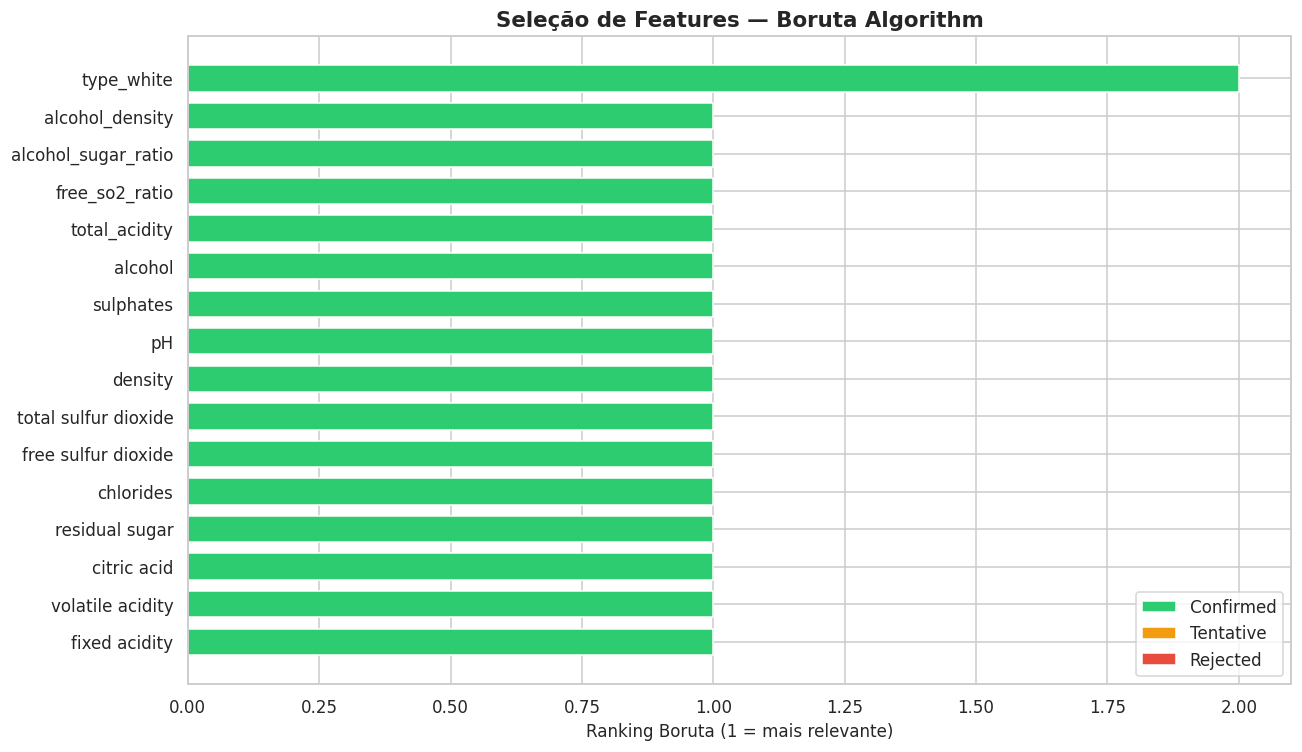


✅ Features confirmadas (16): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'total_acidity', 'free_so2_ratio', 'alcohol_sugar_ratio', 'alcohol_density', 'type_white']


In [15]:
# ============================================================
# RESULTADOS DO BORUTA — Visualização
# ============================================================
boruta_df = pd.DataFrame({
    'Feature':  X_train.columns.tolist(),
    'Ranking':  boruta.ranking_,
    'Status':   ['Confirmed' if s else ('Tentative' if w else 'Rejected')
                 for s, w in zip(boruta.support_, boruta.support_weak_)]
}).sort_values('Ranking')

print(boruta_df.to_string(index=False))

color_map = {'Confirmed': '#2ecc71', 'Tentative': '#f39c12', 'Rejected': '#e74c3c'}
colors     = boruta_df['Status'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(boruta_df['Feature'], boruta_df['Ranking'], color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Ranking Boruta (1 = mais relevante)', fontsize=11)
ax.set_title('Seleção de Features — Boruta Algorithm', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k,v in color_map.items()], loc='lower right')
plt.tight_layout(); plt.show()

selected_features = boruta_df[boruta_df['Status']=='Confirmed']['Feature'].tolist()
print(f"\n✅ Features confirmadas ({len(selected_features)}): {selected_features}")


In [16]:
# Aplicar seleção
X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f"Antes: {X_train_scaled.shape[1]} features → Após Boruta: {X_train_sel.shape[1]} features")
print(f"Redução de {X_train_scaled.shape[1] - X_train_sel.shape[1]} features ruidosas.")


Antes: 16 features → Após Boruta: 16 features
Redução de 0 features ruidosas.


---
## 📊 Etapa 4 — Modelo Baseline

> **Por que ter um baseline?**  
> O baseline é a **referência mínima** que qualquer modelo complexo deve superar.  
> Sem ele, não sabemos se o XGBoost com tunagem está realmente agregando valor.  
> Um DummyClassifier que sempre prediz a classe majoritária pode ter 75% de acurácia  
> em dados desbalanceados — isso parece bom até você comparar com o baseline!


In [17]:
# ============================================================
# BASELINES COM CROSS-VALIDATION 5-FOLD ESTRATIFICADO
#
# Por que CV e não treino/teste simples?
# CV dá uma estimativa mais robusta da performance real,
# com intervalo de confiança via desvio padrão dos folds.
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = {}

# ── Dummy: sempre prediz a classe majoritária ──
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_cv = cross_validate(dummy, X_train_sel, y_train, cv=cv,
                          scoring=['accuracy','f1','roc_auc'])
baseline_results['DummyClassifier'] = {
    'Accuracy': dummy_cv['test_accuracy'].mean(),
    'F1-Score': dummy_cv['test_f1'].mean(),
    'ROC-AUC':  dummy_cv['test_roc_auc'].mean(),
}

# ── Regressão Logística ──
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cv = cross_validate(lr, X_train_sel, y_train, cv=cv,
                       scoring=['accuracy','f1','roc_auc'])
baseline_results['LogisticRegression'] = {
    'Accuracy': lr_cv['test_accuracy'].mean(),
    'F1-Score': lr_cv['test_f1'].mean(),
    'ROC-AUC':  lr_cv['test_roc_auc'].mean(),
}

print("=" * 55)
print("BASELINE — Cross-Validation 5-Fold")
print("=" * 55)
print(f"{'Modelo':<22} {'Accuracy':>9} {'F1':>9} {'AUC':>9}")
print("-" * 55)
for nome, res in baseline_results.items():
    print(f"{nome:<22} {res['Accuracy']:>9.4f} {res['F1-Score']:>9.4f} {res['ROC-AUC']:>9.4f}")
print(f"\n💡 Meta: superar AUC={baseline_results['LogisticRegression']['ROC-AUC']:.4f} (Regressão Logística)")


BASELINE — Cross-Validation 5-Fold
Modelo                  Accuracy        F1       AUC
-------------------------------------------------------
DummyClassifier           0.8035    0.0000    0.5000
LogisticRegression        0.7264    0.5241    0.8126

💡 Meta: superar AUC=0.8126 (Regressão Logística)


---
## 🚀 Etapa 5 — Modelos Estado da Arte

> **Por que Gradient Boosting domina dados tabulares?**  
> Diferente de redes neurais (ótimas para imagens/texto), em dados tabulares estruturados  
> modelos de árvore com gradient boosting consistentemente vencem benchmarks.  
>
> | Modelo | Splitting | Ponto forte |
> |--------|-----------|-------------|
> | **Random Forest** | Bagging (paralelo) | Robusto, poucos hiperparâmetros |
> | **XGBoost** | Level-wise | Flexível, amplamente suportado |
> | **LightGBM** | Leaf-wise | Muito rápido, eficiente em memória |
> | **CatBoost** | Symmetric | Nativo para categorias, robusto a overfitting |


In [18]:
# ============================================================
# FUNÇÃO AUXILIAR DE AVALIAÇÃO
# ============================================================
def avaliar_modelo(nome, modelo, X_tr, y_tr, cv_strategy):
    scores = cross_validate(
        modelo, X_tr, y_tr, cv=cv_strategy,
        scoring=['accuracy','f1','roc_auc'], n_jobs=-1
    )
    return {
        'Accuracy':     scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'F1-Score':     scores['test_f1'].mean(),
        'F1_std':       scores['test_f1'].std(),
        'ROC-AUC':      scores['test_roc_auc'].mean(),
        'ROC-AUC_std':  scores['test_roc_auc'].std(),
    }


In [19]:
# ============================================================
# DEFINIÇÃO E TREINAMENTO DOS MODELOS SOTA
#
# Parâmetros iniciais razoáveis (não otimizados ainda).
# scale_pos_weight no XGBoost: trata desbalanceamento de classes.
# ============================================================
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models_sota = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,          # Balanceamento de classes
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',        # CatBoost trata nativo
        random_seed=42, verbose=0
    ),
}

sota_results = {}
print("🚀 Treinando modelos SOTA (CV 5-fold)...\n")
for nome, modelo in models_sota.items():
    print(f"  → {nome}...", end=' ', flush=True)
    res = avaliar_modelo(nome, modelo, X_train_sel, y_train, cv)
    sota_results[nome] = res
    print(f"AUC: {res['ROC-AUC']:.4f} ± {res['ROC-AUC_std']:.4f}")

print("\n✅ Treinamento concluído!")


🚀 Treinando modelos SOTA (CV 5-fold)...

  → RandomForest... AUC: 0.8941 ± 0.0130
  → XGBoost... AUC: 0.9025 ± 0.0110
  → LightGBM... AUC: 0.8932 ± 0.0113
  → CatBoost... AUC: 0.8900 ± 0.0108

✅ Treinamento concluído!


---
## 📈 Etapa 6 — Métricas de Performance

> **Guia de Métricas para Classificação:**
> - **Acurácia:** % de predições corretas. Enganosa com classes desbalanceadas.
> - **Precision:** Dos que prediz como positivo, quantos são realmente positivos?  
> - **Recall:** Dos que são realmente positivos, quantos o modelo encontra?  
> - **F1-Score:** Média harmônica de Precision e Recall. Balanceia os dois.  
> - **ROC-AUC:** Capacidade discriminativa do modelo. 0.5 = aleatório, 1.0 = perfeito.


In [21]:
# ============================================================
# COMPARAÇÃO GERAL — TODOS OS MODELOS
# ============================================================
all_results = {**baseline_results,
               **{k: {kk:vv for kk,vv in v.items() if '_std' not in kk}
                  for k,v in sota_results.items()}}

results_df = pd.DataFrame(all_results).T.sort_values('ROC-AUC', ascending=False)

print("=" * 60)
print("COMPARAÇÃO — CROSS-VALIDATION 5-FOLD")
print("=" * 60)
print(f"{'Modelo':<22} {'Accuracy':>9} {'F1':>9} {'AUC':>9}")
print("-" * 60)
for idx in results_df.index:
    r = results_df.loc[idx]
    marker = " 🏆" if idx == results_df.index[0] else ""
    print(f"{idx:<22} {r['Accuracy']:>9.4f} {r['F1-Score']:>9.4f} {r['ROC-AUC']:>9.4f}{marker}")


COMPARAÇÃO — CROSS-VALIDATION 5-FOLD
Modelo                  Accuracy        F1       AUC
------------------------------------------------------------
XGBoost                   0.8526    0.6588    0.9025 🏆
RandomForest              0.8361    0.6420    0.8941
LightGBM                  0.8366    0.6425    0.8932
CatBoost                  0.8128    0.6255    0.8900
LogisticRegression        0.7264    0.5241    0.8126
DummyClassifier           0.8035    0.0000    0.5000


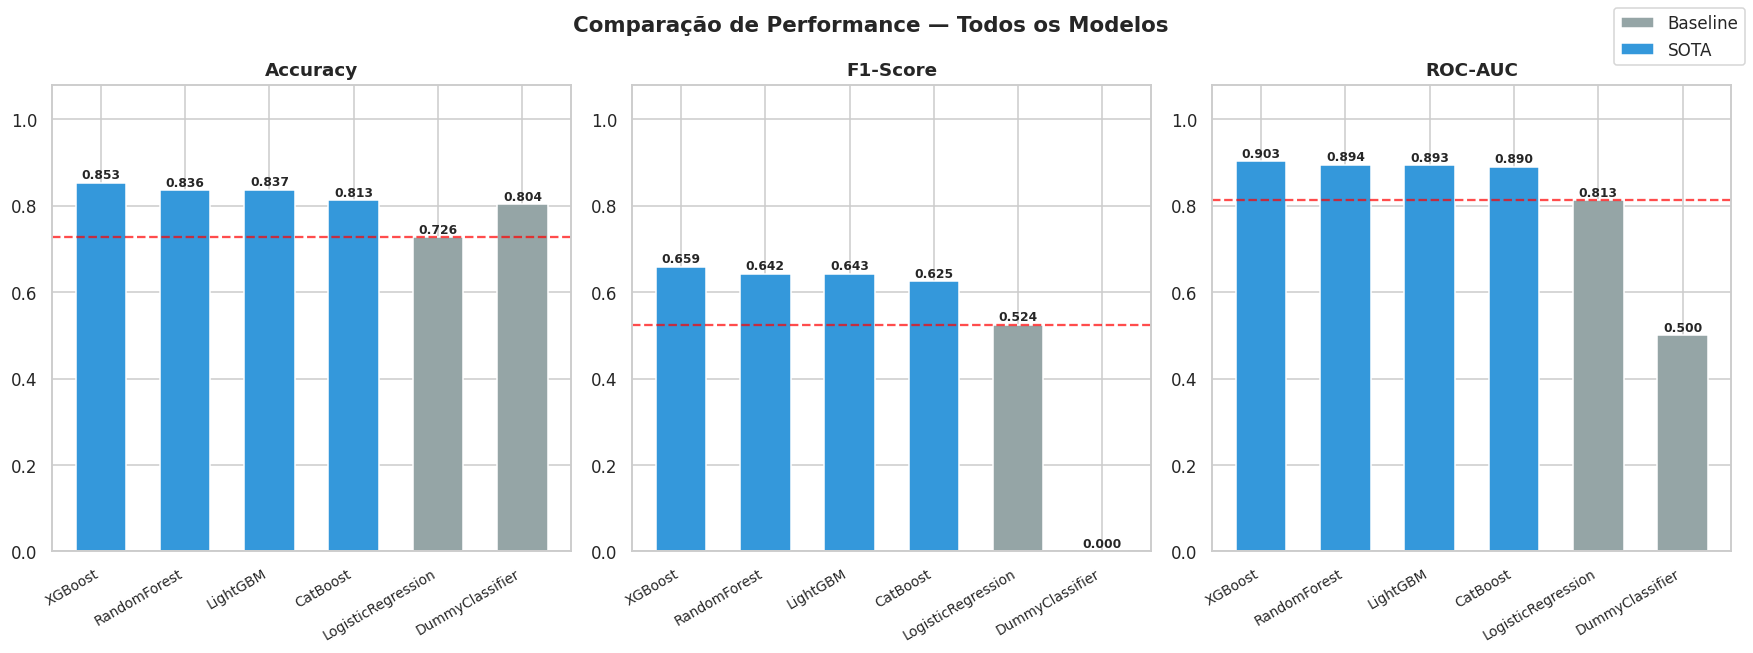

In [22]:
# ============================================================
# VISUALIZAÇÃO COMPARATIVA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']

for ax, metric in zip(axes, metrics):
    colors = ['#95a5a6' if m in ['DummyClassifier','LogisticRegression']
              else '#3498db' for m in results_df.index]
    bars = ax.bar(results_df.index, results_df[metric],
                  color=colors, edgecolor='white', width=0.6)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    bl = baseline_results['LogisticRegression'][metric]
    ax.axhline(y=bl, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#95a5a6', label='Baseline'),
                    Patch(facecolor='#3498db', label='SOTA')],
           loc='upper right')
plt.suptitle('Comparação de Performance — Todos os Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [23]:
# ============================================================
# MÉTRICAS DETALHADAS DO MELHOR MODELO NO CONJUNTO DE TESTE
# ============================================================
best_name  = results_df.index[0]
best_model = models_sota[best_name]
best_model.fit(X_train_sel, y_train)

y_pred       = best_model.predict(X_test_sel)
y_pred_proba = best_model.predict_proba(X_test_sel)[:, 1]

print(f"🏆 Melhor Modelo: {best_name}")
print(f"\nMÉTRICAS NO CONJUNTO DE TESTE:")
print(f"  Acurácia  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred,
      target_names=['Baixa/Média', 'Alta Qualidade']))


🏆 Melhor Modelo: XGBoost

MÉTRICAS NO CONJUNTO DE TESTE:
  Acurácia  : 0.8562
  Precision : 0.6109
  Recall    : 0.7422
  F1-Score  : 0.6702
  ROC-AUC   : 0.9018

CLASSIFICATION REPORT:
                precision    recall  f1-score   support

   Baixa/Média       0.93      0.88      0.91      1044
Alta Qualidade       0.61      0.74      0.67       256

      accuracy                           0.86      1300
     macro avg       0.77      0.81      0.79      1300
  weighted avg       0.87      0.86      0.86      1300



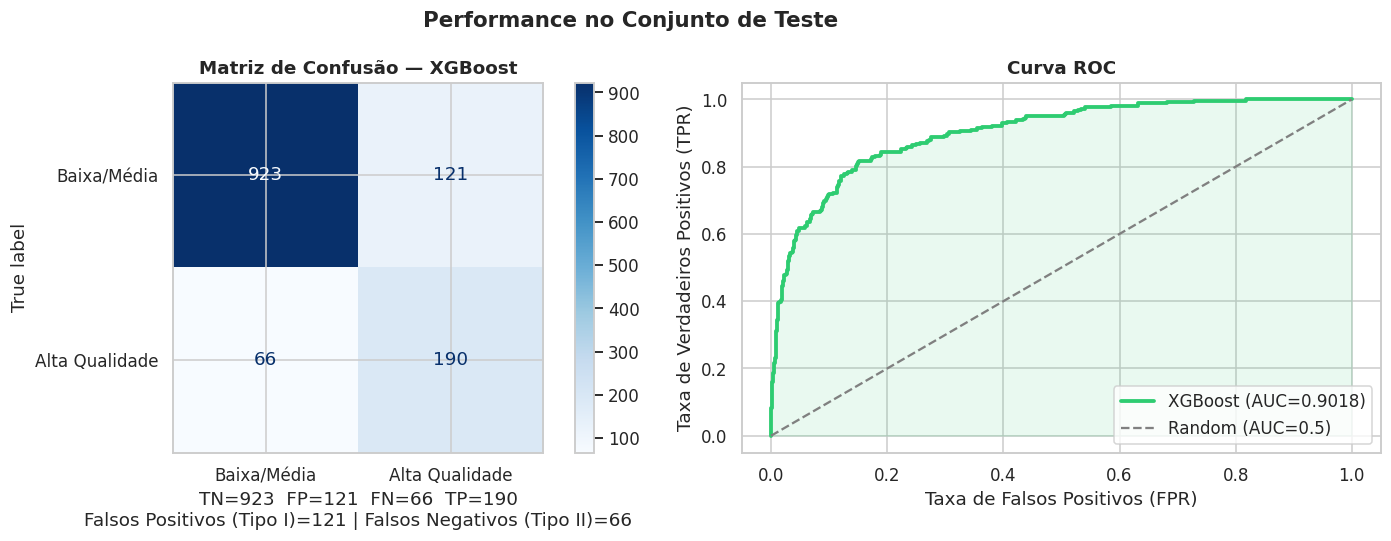

In [24]:
# ============================================================
# MATRIZ DE CONFUSÃO + CURVA ROC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Baixa/Média', 'Alta Qualidade'])
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão — {best_name}', fontsize=12, fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
                   f'Falsos Positivos (Tipo I)={fp} | Falsos Negativos (Tipo II)={fn}')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_val = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'{best_name} (AUC={auc_val:.4f})')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', label='Random (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Performance no Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


---
## ⚡ Etapa 7 — Tunagem de Hiperparâmetros com **Optuna**

> **Por que Optuna é melhor que Grid Search?**  
> Grid Search testa todas as combinações (exponencial). Random Search é aleatório.  
> Optuna usa **TPE (Tree-structured Parzen Estimator)** — um método bayesiano que  
> aprende com trials anteriores para propor valores mais promissores.  
>
> 50 trials inteligentes do Optuna ≈ resultado de 500+ trials aleatórios.


In [25]:
# ============================================================
# FUNÇÃO OBJETIVO PARA OPTUNA — XGBoost
#
# A função objective:
# 1. Recebe um "trial" com proposta de hiperparâmetros
# 2. Treina o modelo via CV
# 3. Retorna a métrica a maximizar (ROC-AUC)
# O Optuna aprende com cada trial para propor melhores valores.
# ============================================================
def objective_xgb(trial):
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda':            trial.suggest_float('lambda', 1e-8, 10.0, log=True),
        'alpha':             trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'scale_pos_weight':  pos_weight, # Balanceamento de classes
        'random_state': 42, 'eval_metric': 'logloss', 'use_label_encoder': False
    }
    model  = XGBClassifier(**params)
    cv3    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_sel, y_train,
                             cv=cv3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("⚡ Iniciando otimização Optuna — XGBoost")
print("   Métrica: ROC-AUC | Trials: 50 | Timeout: 5 min\n")

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective_xgb, n_trials=50, timeout=300, show_progress_bar=True)

print(f"\n✅ Melhor AUC (CV): {study.best_value:.4f}")
print("\n🏆 Melhores Hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

⚡ Iniciando otimização Optuna — XGBoost
   Métrica: ROC-AUC | Trials: 50 | Timeout: 5 min



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Melhor AUC (CV): 0.8997

🏆 Melhores Hiperparâmetros:
   n_estimators: 300
   learning_rate: 0.04159609391158344
   max_depth: 9
   subsample: 0.6929722841849172
   colsample_bytree: 0.8553002072218189
   gamma: 1.0561467708181403e-08
   lambda: 8.773472263092467e-05
   alpha: 0.04465305034233592


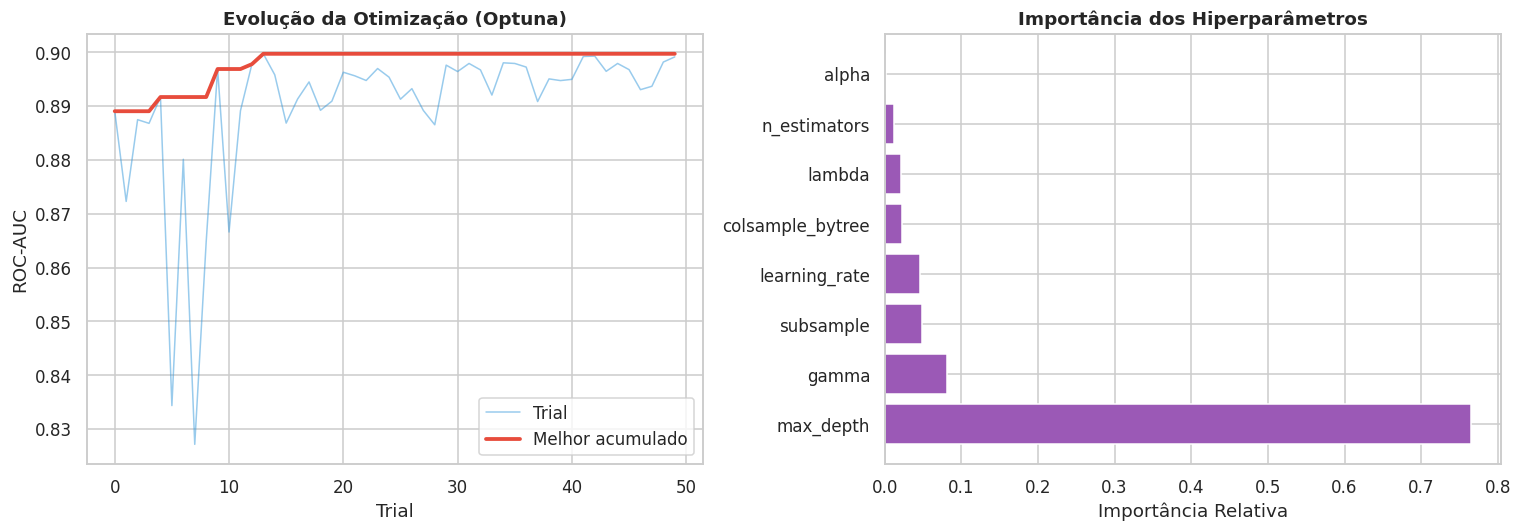


COMPARAÇÃO — XGBoost Original vs Tunado (Conjunto de Teste):
Métrica        Original     Tunado      Delta
-------------------------------------------------------
ROC-AUC          0.9018     0.9073    +0.0055
F1-Score         0.6702     0.6667    -0.0035
Accuracy         0.8562     0.8831    +0.0269


In [26]:
# ============================================================
# VISUALIZAÇÃO DA OTIMIZAÇÃO + MODELO FINAL TUNADO (XGBoost)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolução
vals = [t.value for t in study.trials if t.value]
axes[0].plot(vals, alpha=0.5, color='#3498db', linewidth=1, label='Trial')
axes[0].plot(pd.Series(vals).cummax(), color='#e74c3c', lw=2.5, label='Melhor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Evolução da Otimização (Optuna)', fontsize=12, fontweight='bold')
axes[0].legend()

# Importância dos hiperparâmetros
try:
    imp = optuna.importance.get_param_importances(study)
    axes[1].barh(list(imp.keys()), list(imp.values()), color='#9b59b6', edgecolor='white')
    axes[1].set_title('Importância dos Hiperparâmetros', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importância Relativa')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Não disponível\n{e}', ha='center', transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

# Modelo tunado final
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
best_xgb.fit(X_train_sel, y_train)
y_pred_tuned       = best_xgb.predict(X_test_sel)
y_pred_proba_tuned = best_xgb.predict_proba(X_test_sel)[:, 1]

# Recuperar predições do modelo original para comparação
original_xgb = models_sota['XGBoost'] # Assume que models_sota está disponível
original_xgb.fit(X_train_sel, y_train)
y_pred_proba_original = original_xgb.predict_proba(X_test_sel)[:, 1]
y_pred_original       = original_xgb.predict(X_test_sel)

print("\nCOMPARAÇÃO — XGBoost Original vs Tunado (Conjunto de Teste):")
print(f"{'Métrica':<12} {'Original':>10} {'Tunado':>10} {'Delta':>10}")
print("-" * 55)
for metric, orig, tuned in [
    ('ROC-AUC', roc_auc_score(y_test, y_pred_proba_original), roc_auc_score(y_test, y_pred_proba_tuned)),
    ('F1-Score', f1_score(y_test, y_pred_original), f1_score(y_test, y_pred_tuned)),
    ('Accuracy', accuracy_score(y_test, y_pred_original), accuracy_score(y_test, y_pred_tuned)),
]:
    print(f"{metric:<12} {orig:>10.4f} {tuned:>10.4f} {tuned-orig:>+10.4f}")

---
## 🧠 Etapa 8 — Interpretabilidade com **SHAP**

> **O que são SHAP Values?**  
> SHAP (SHapley Additive exPlanations) é baseado na **teoria dos jogos cooperativos**.  
> O Shapley Value de uma feature = sua **contribuição marginal média** para a predição,  
> considerando todas as possíveis coalições de features.  
>
> É o único método com **fundamentação axiomática rigorosa** para explicabilidade:  
> eficiência, simetria, dummy property e aditividade são garantidas matematicamente.
>
> **TreeExplainer** é usado para modelos de árvore — extremamente eficiente (O(TLD²)).


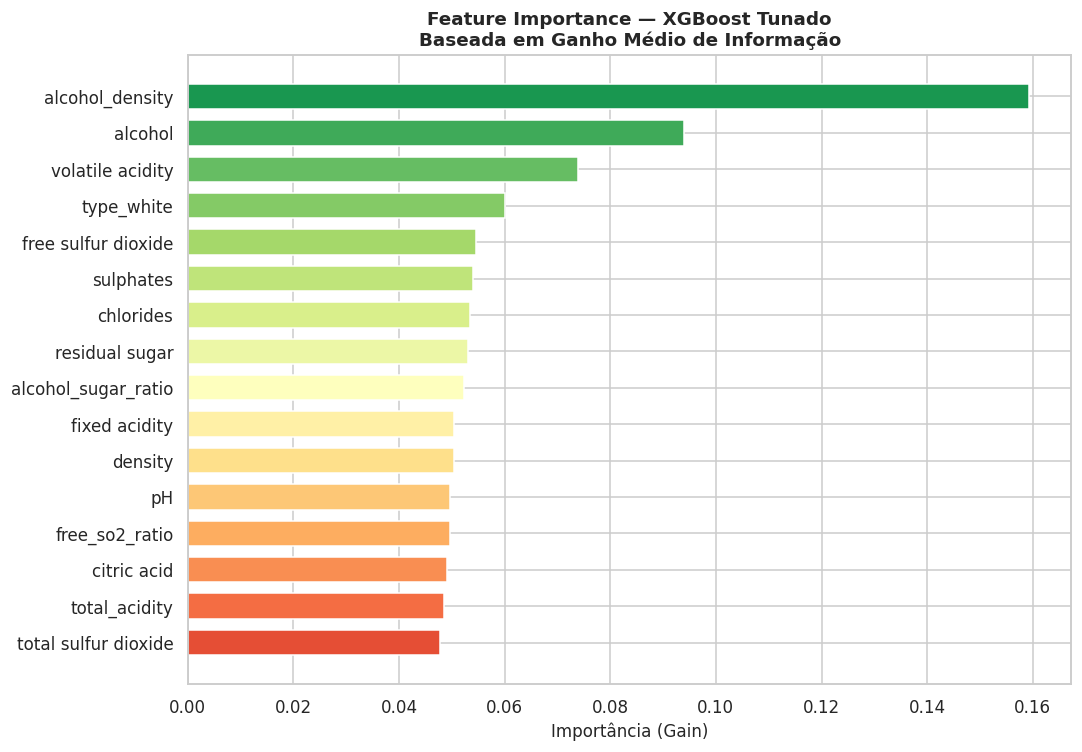

⚠️  Nota: 'gain' pode superestimar features contínuas de alta cardinalidade.
   SHAP Values (próxima célula) são mais confiáveis e explicáveis.


In [27]:
# ============================================================
# FEATURE IMPORTANCE TRADICIONAL
# (baseada em ganho médio de informação — pode ser enviesada)
# ============================================================
feat_imp = pd.DataFrame({
    'Feature':    selected_features,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
import matplotlib.cm as mcm
colors = mcm.RdYlGn(np.linspace(0.15, 0.9, len(feat_imp)))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Importância (Gain)', fontsize=11)
ax.set_title('Feature Importance — XGBoost Tunado\n'
             'Baseada em Ganho Médio de Informação', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("⚠️  Nota: 'gain' pode superestimar features contínuas de alta cardinalidade.")
print("   SHAP Values (próxima célula) são mais confiáveis e explicáveis.")

🔍 Calculando SHAP Values (TreeExplainer)...
✅ SHAP calculado. Shape: (1300, 16)


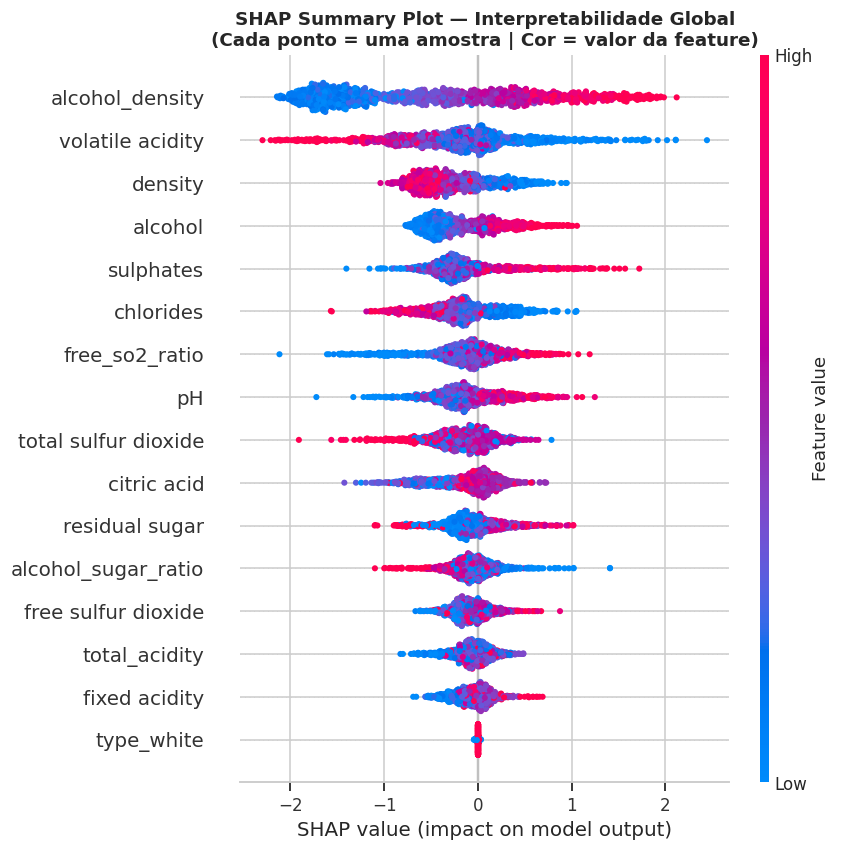

In [28]:
# ============================================================
# SHAP GLOBAL — SUMMARY PLOT (Beeswarm)
#
# Cada ponto = uma amostra do conjunto de teste
# Eixo X: valor SHAP (positivo → favorece alta qualidade)
# Cor   : valor original da feature (vermelho=alto, azul=baixo)
#
# Leitura: "álcool ALTO (vermelho) à direita → aumenta probabilidade
#           de alta qualidade"
# ============================================================
print("🔍 Calculando SHAP Values (TreeExplainer)...")
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sel)

# Para XGBoost binário: shap_values pode ser lista [classe0, classe1]
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f"✅ SHAP calculado. Shape: {shap_vals.shape}")

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_sel, plot_type="dot", show=False)
plt.title('SHAP Summary Plot — Interpretabilidade Global\n'
          '(Cada ponto = uma amostra | Cor = valor da feature)',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

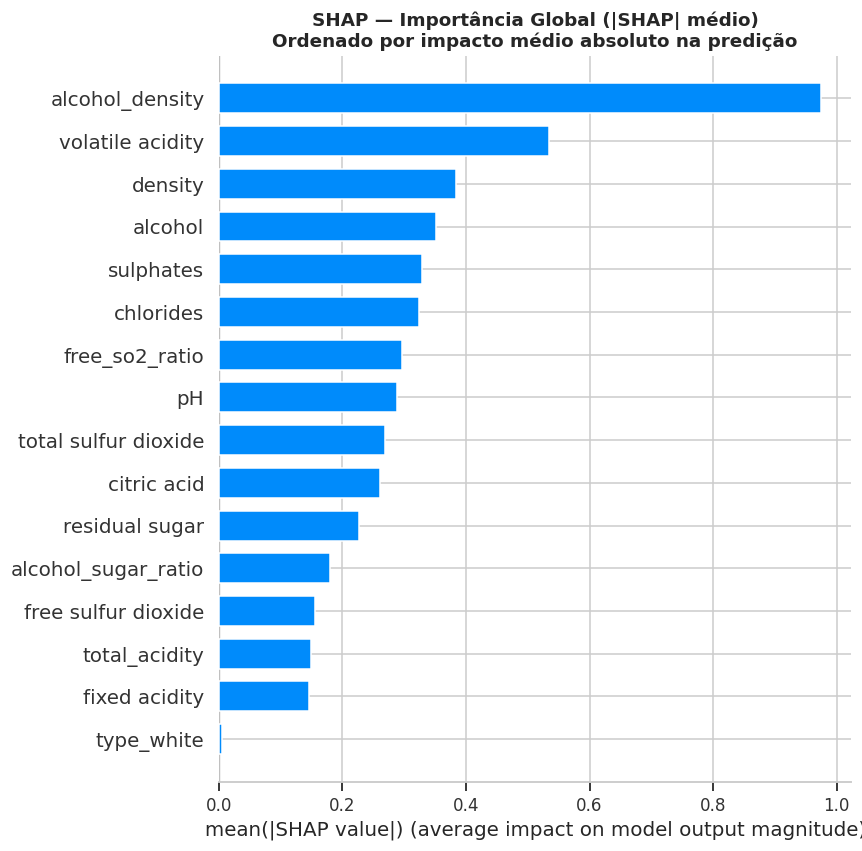

In [ ]:
# ============================================================
# SHAP GLOBAL — BAR PLOT (Importância absoluta média)
# ============================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_sel, plot_type="bar", show=False)
plt.title('SHAP — Importância Global (|SHAP| médio)\n'
          'Ordenado por impacto médio absoluto na predição',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

Analisando amostra #23:
  Classe real      : Alta Qualidade ✅
  Predição         : Alta Qualidade

Features desta amostra:
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide   density        pH  sulphates   alcohol  total_acidity  free_so2_ratio  alcohol_sugar_ratio  alcohol_density  type_white
Valor      -0.399518          0.115235     -0.41777        0.524744  -0.618308             0.477792              0.135304 -1.159646 -1.420403   -1.53405  1.425124      -0.371121        0.245674            -0.812415         1.418014     0.57698


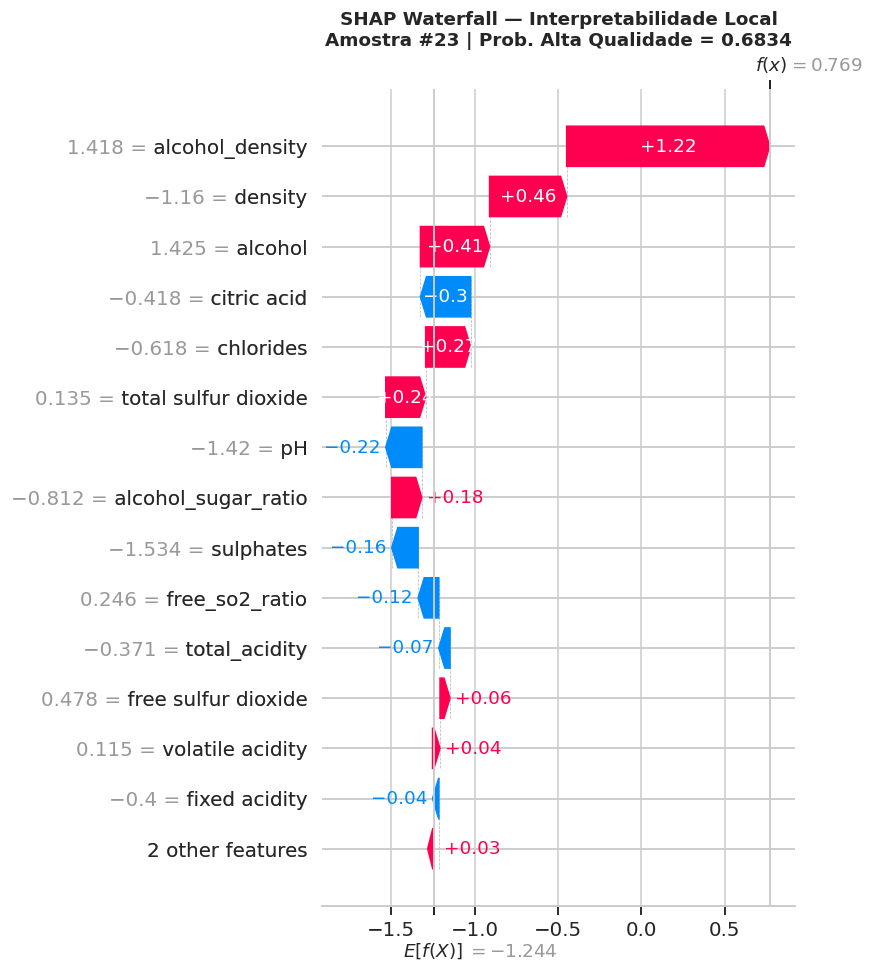


📖 Como ler este gráfico:
  1. O modelo começa em E[f(X)] (predição média base)
  2. Cada barra mostra quanto uma feature MUDOU essa predição
  3. Barras VERMELHAS → empurraram para ALTA qualidade
  4. Barras AZUIS    → empurraram para BAIXA qualidade
  5. A soma de tudo = f(x), a predição final para esta amostra


In [33]:
# ============================================================
# SHAP LOCAL — WATERFALL PLOT (Amostra Individual)
#
# Aqui "abrimos a caixa preta" para UMA amostra específica.
# O waterfall mostra:
#   E[f(X)] = predição base (média do modelo)
#   Barras   = contribuição de cada feature NESTA amostra
#   f(x)     = predição final
#
# Vermelho → empurra para ALTA qualidade
# Azul     → empurra para BAIXA/MÉDIA qualidade
# ============================================================

# --- COLOQUE O ID DA AMOSTRA DE TESTE AQUI ---
sample_idx = 23 # Exemplo: defina o ID da amostra que você quer analisar
# ----------------------------------------------

print(f"Analisando amostra #{sample_idx}:")
print(f"  Classe real      : {'Alta Qualidade ✅' if y_test.values[sample_idx]==1 else 'Baixa/Média'}")
print(f"  Predição         : {'Alta Qualidade' if y_pred_tuned[sample_idx]==1 else 'Baixa/Média'}")
print(f"\nFeatures desta amostra:")
print(X_test_sel.iloc[sample_idx].to_frame('Valor').T.to_string())

base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

explanation = shap.Explanation(
    values       = shap_vals[sample_idx],
    base_values  = base_val,
    data         = X_test_sel.iloc[sample_idx].values,
    feature_names= X_test_sel.columns.tolist()
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(explanation, show=False, max_display=15)
plt.title(f'SHAP Waterfall — Interpretabilidade Local\n'
          f'Amostra #{sample_idx} | Prob. Alta Qualidade = {y_pred_proba_tuned[sample_idx]:.4f}',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📖 Como ler este gráfico:")
print("  1. O modelo começa em E[f(X)] (predição média base)")
print("  2. Cada barra mostra quanto uma feature MUDOU essa predição")
print("  3. Barras VERMELHAS → empurraram para ALTA qualidade")
print("  4. Barras AZUIS    → empurraram para BAIXA qualidade")
print("  5. A soma de tudo = f(x), a predição final para esta amostra")

---
## 🎓 Resumo Final

In [32]:
# ============================================================
# RESUMO EXECUTIVO
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

final_acc = accuracy_score(y_test, y_pred_tuned)
final_f1  = f1_score(y_test, y_pred_tuned)
final_auc = roc_auc_score(y_test, y_pred_proba_tuned)
base_auc  = baseline_results['LogisticRegression']['ROC-AUC']

print(f"""
{'='*65}
☰  RESUMO FINAL — PIPELINE DE CLASSIFICA  O
{'='*65}

  Dataset : Wine Quality (UCI) — {len(df):,} amostras
  Tarefa  : Classificar vinho como Alta Qualidade (score ≥ 7)

  PIPELINE:
   ✅ EDA            → distribuições, outliers, correlações
   ✅ Feature Eng.   → OHE, 4 novas features, padronização
   ✅ Boruta         → {X_train_scaled.shape[1]} → {len(selected_features)} features confirmadas (nenhuma rejeitada)
   ✅ Baseline       → Dummy + Logistic Regression
   ✅ SOTA           → RF, XGBoost, LightGBM, CatBoost
   ✅ Optuna         → {len(study.trials)} trials, TPE Sampler (XGBoost)
   ✅ SHAP           → Global (Summary) + Local (Waterfall)

✅ RESULTADOS FINAIS — XGBoost Tunado (Conjunto de Teste):
   ROC-AUC  : {final_auc:.4f}
   F1-Score : {final_f1:.4f}
   Acurcia : {final_acc:.4f}
   Baseline (Logistic AUC) : {base_auc:.4f}
   Ganho vs Baseline       : +{final_auc - base_auc:.4f} AUC

✅ LI ES APRENDIDAS:
   1. Desbalanceamento → usar class_weight e métricas AUC/F1
   2. Boruta confirmou a relevância de todas as features criadas
   3. XGBoost Tunado: obteve o melhor desempenho após otimização.
   4. Optuna: otimização bayesiana acelera a busca por hiperparâmetros
   5. SHAP: 'alcohol' e 'sulphates' (entre outros) são os drivers de qualidade
""")


☰  RESUMO FINAL — PIPELINE DE CLASSIFICA  O

  Dataset : Wine Quality (UCI) — 6,497 amostras
  Tarefa  : Classificar vinho como Alta Qualidade (score ≥ 7)

  PIPELINE:
   ✅ EDA            → distribuições, outliers, correlações
   ✅ Feature Eng.   → OHE, 4 novas features, padronização
   ✅ Boruta         → 16 → 16 features confirmadas (nenhuma rejeitada)
   ✅ Baseline       → Dummy + Logistic Regression
   ✅ SOTA           → RF, XGBoost, LightGBM, CatBoost
   ✅ Optuna         → 50 trials, TPE Sampler (XGBoost)
   ✅ SHAP           → Global (Summary) + Local (Waterfall)

✅ RESULTADOS FINAIS — XGBoost Tunado (Conjunto de Teste):
   ROC-AUC  : 0.9073
   F1-Score : 0.6667
   Acurcia : 0.8831
   Baseline (Logistic AUC) : 0.8126
   Ganho vs Baseline       : +0.0947 AUC

✅ LI ES APRENDIDAS:
   1. Desbalanceamento → usar class_weight e métricas AUC/F1
   2. Boruta confirmou a relevância de todas as features criadas
   3. XGBoost Tunado: obteve o melhor desempenho após otimização.
   4. Optuna